# What is this notebook about?

Here we learn how to build maps from SIMuRG base file which stores time series data like:

```
HDF_FILE
    -> site1 (attributes: lat, lon)
    -> site2 (attributes: lat, lon)
    -> site3 (attributes: lat, lon)
        -> sat1
            -> timestamp
            -> azimuth 
            -> dtec_10_20
            -> dtec_20_60
            -> dtec_2_10
            -> elevation
            -> roti
            -> tec
            -> tec_adjusted
        -> sat2
            -> data
        ...
    ...
    -> siteN (attributes: lat, lon)
```

In the end we got files structured as (which is SIMuRG format for spatial map storage):

```
HDF_FILE
    -> data
        -> timestamp1       (structured array)
            .. latitutdes   (column)
            .. longitudes   (column) 
            .. values       (column) 
        -> timestamp2
            .. latitutdes 
            .. longitudes
            .. values

        ....

       -> timestampN
            .. latitutdes 
            .. longitudes
            .. values
    -> metadata
```


In [75]:
!pip install git+https://github.com/gnss-lab/simurg_core.git

  Cloning https://github.com/gnss-lab/simurg_core.git to /tmp/pip-req-build-kgwmt_vh
  Running command git clone --filter=blob:none --quiet https://github.com/gnss-lab/simurg_core.git /tmp/pip-req-build-kgwmt_vh
  Resolved https://github.com/gnss-lab/simurg_core.git to commit 3a929fedbda71f16c46cbd4fa4a363d461a3c007
  Preparing metadata (setup.py) ... done


In [99]:
from dateutil import tz
from datetime import datetime
import tempfile
from pathlib import Path

working_dir = Path(tempfile.gettempdir()) / "simurg_maps_builder"
working_dir.mkdir(exist_ok=True)

_UTC = tz.gettz('UTC')
SIMURG_MAP_TIME_KEY_FORMAT = '%Y-%m-%d %H:%M:%S.%f'

study_date = datetime(2025, 1, 5).replace(tzinfo=_UTC)
series_file = working_dir / study_date.strftime("%Y-%m-%d.h5")
maps_files = []

data_products = ['roti', 'dtec_2_10']
for product in data_products:
    maps_files.append(working_dir / (product + "_" +  study_date.strftime("maps_%Y-%m-%d.h5")))

In [79]:
from dataclasses import dataclass

@dataclass
class SimurgDataFile():
    url: str
    local_path: Path

### Function for data download 

Futher develop function for data download. Variable `override` defines whther data should be downloaded in anyway or only when they not available locally. Function introduces progress bar via `response.iter_content()` and `sys.stdout.write()`, `sys.stdout.flush()`. The progress bar looks like:

```bash
Downloading 2025-01-05.h5 from https://simurg.space/gen_file?data=obs&date=2025-01-05
[===========================                        ]
```

In [80]:
import requests
import os
import sys
from pathlib import Path
import logging

logging.getLogger("requests").setLevel(logging.WARNING)
logging.getLogger("urllib3").setLevel(logging.WARNING)

def load_data(
    url: str, 
    local_file: Path,
    override: bool = False
) -> None:
    if local_file.exists() and not override:
        print(f"File {local_file} exists. Use override=True to download it again.")
        return 
        
    with open(local_file, "wb") as f:
        print(f"Downloading {local_file} from {url}")
        response = requests.get(url, stream=True)
        total_length = response.headers.get('content-length')

        if total_length is None: 
            f.write(response.content)
        else:
            dl = 0
            previous = 0
            total_length = int(total_length)
            for chunk in response.iter_content(chunk_size=4096):
                dl += len(chunk)
                f.write(chunk)
                done = int(50 * dl / total_length)
                if done > previous: # to prevent warnings from notebook
                    sys.stdout.write("\r[%s%s]" % ('=' * done, ' ' * (50-done)) )    
                    sys.stdout.flush()
                previous = done
            sys.stdout.write("\n")

### Data download

Now we are ready to call `load_data()`.

> **To work with your data change link `simurg.space/gen_file?data=obs&date=2025-01-05.h5` to proper one.**

> Make sure you have `override=True` or different `Path("roti.h5")` if change url.

In [81]:
from datetime import datetime
from dateutil import tz

series_files = {
    study_date: SimurgDataFile(
        f"https://simurg.space/gen_file?data=obs&date={filename[:-3]}", # on simurg.space extension '.h5' is not used
        Path(series_file),
    ),
}
for date, data_file in series_files.items():
    load_data(data_file.url, data_file.local_path, override=True)

[==================================================]


## Site coordinates

To build a map we need site coordinates. Don't worry - they are in th same SIMuRG file as observation time series. Function `get_sites_coordinates()` will do the job:

In [84]:
import h5py

def get_sites_coordinates(data_path: Path):
    """
    :param data_path: Path
        Path to HDF5 file retrieved from SIMuRG
    """
    sites_dict = {}
    with h5py.File(data_path, 'r') as f:
        for site in f:
            lat = f[site].attrs['lat']
            lon = f[site].attrs['lon']
            sites_dict[site] = {'name': site, 'location':(lat, lon)} 
        f.close()
    return sites_dict

In [85]:
coords = get_sites_coordinates(series_files[study_date].local_path)
print(f"Retrieved coordinates for {len(coords)} sites")
for site in coords:
    print(f"For {site} retrieved {coords[site]}")
    break # this loop just for illustration there are data

Retrieved coordinates for 200 sites
For albh retrieved {'name': 'albh', 'location': (0.8445610153758825, -2.1552629296109136)}


In [102]:
import time
import pytz

import sys
from pathlib import Path
sys.path.append("./core/")

from datetime import datetime
from datetime import timedelta

from simurg_core.storage.hdf_query import get_map_chunked
from simurg_core.storage.hdf_storage import get_sites_attrs
from simurg_core.storage.hdf_maps import store_maps_time_based
from simurg_core.storage.hdf_storage import get_filename

file_path = series_files[study_date].local_path
print(file_path)
if not Path(file_path).exists():
    raise ValueError(f"Could not find {file_path}")

sites_description = get_sites_attrs(file_path)

times = []
# Assume all day data with 30 seconds timestep 24 * 3600 / 30 = 2880
# For more accurate times use times in files
for i in range(0, 240):
    times.append(study_date + timedelta(0,int(30*i)))

print(f"Working for times from {times[0]} to {times[-1]}")
query = {'sites': 'sites'} 

start = time.time()
print('Starting query for {} sites at {} '.format(len(sites_description), start))    
generator = get_map_chunked(
    sites_description, 
    times, 
    file_path = file_path, 
    product_types=data_products, # replace data product here if you need  
    roti_type = 'simple',
    chunk=120
)
iprod = 0
for data in generator:
    print('Took {}'.format(time.time() - start))
    maps_file = maps_files[iprod % len(data_products)]
    store_maps_time_based(query, data, str(maps_file))
    iprod = iprod + 1
print('For {} sites it took {} seconds to get maps'.format(len(sites_description), time.time() - start))

/tmp/simurg_maps_builder/2025-01-05.h5
Working for times from 2025-01-05 00:00:00+00:00 to 2025-01-05 01:59:30+00:00
Starting query for 200 sites at 1764746979.3597164 
Took 13.185041904449463
Took 18.86105227470398
Took 34.31696009635925
Took 40.57925224304199
For 200 sites it took 40.65316653251648 seconds to get maps


## Validate maps via visualization

The easiest way to validate data is to plot it. We expect data draw coaslines since receivers are placed on the land and missing in oceans as well as be more dense in regions with more gnss recesivers.

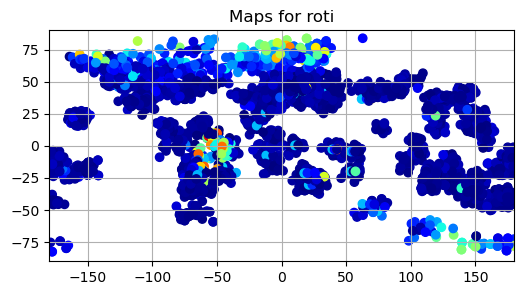

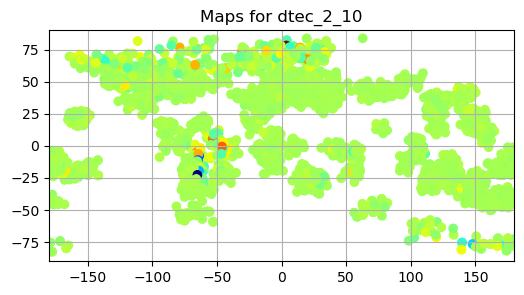

In [109]:
import matplotlib.pyplot as plt
import numpy as np

for maps_file, product in zip(maps_files, data_products):
    times = []
    maps = {}
    with h5py.File(maps_file, 'r') as f:
        for str_time in f['data']:
            epoch = datetime.strptime(str_time, SIMURG_MAP_TIME_KEY_FORMAT)
            times.append(epoch)
            maps[epoch] = f['data'][str_time][:]
    sample_time = times[42]
    sample_map = maps[sample_time]
    plt.figure(figsize=(6, 3))
    plt.grid()
    plt.scatter(sample_map['lon'], sample_map['lat'], c=sample_map['vals'], cmap="jet")
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.title(f"Maps for {product}")
    
    plt.show()